# **Sales Analysis**

In [150]:
import pandas as pd
import numpy
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from matplotlib.ticker import FuncFormatter

In [151]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [152]:
def currency_formatter(x, _):
    if x >= 1_000_000_000:
        val = x / 1e9
        return f'${val:.1f}B'.replace('.0B', 'B')
    elif x >= 1_000_000:
        val = x / 1e6
        return f'${val:.1f}M'.replace('.0M', 'M')
    elif x >= 1_000:
        val = x / 1e3
        return f'${val:.1f}K'.replace('.0K', 'K')
    else:
        return f'${x:,.0f}'

In [153]:
sales_df = pd.read_csv(
    'dataset/processed/ecommerce_processed.csv',
    parse_dates=['order_date']
)

In [154]:
sales_df.sample(10)

,order_date,order_year,order_month,order_day_of_week,part_day,is_weekend,customer_name,gender,age,age_group,customer_segment,country,order_status,category,sub_category,unit_price_usd,price_tier,quantity,quantity_segment,gross_revenue_usd,discount_amount_usd,discount_percent,discount_tier,is_discounted,net_revenue_usd,order_value_segment,profit_usd,profit_margin_percent,payment_method,shipping_method,shipping_cost_usd,shipping_cost_percent,delivery_days,delivery_speed,shipping_country,shipment_type,rating,customer_loyalty_score,loyalty_tier,coupon_used,session_duration_min,engagement_level,pages_visited,abandoned_cart_before,fraud_risk_score,fraud_risk_level,device_type,campaign_source,traffic_source
884892,2024-04-01 01:23:19.421350,2024,4,Mon,Night,No,Cynthia Hansen,Female,43,35-44,Regular,Germany,Completed,Clothing,Accessories,138.49,Premium,4,Bulk,553.96,0.00,0,No Discount,No,553.96,High,251.80,45.45,Debit Card,Next Day,3.14,0.57,9,Slow,Germany,Domestic,5,89.00,High,No,22.00,Medium,8,Yes,96.30,High,Mobile,Organic,Email
775500,2025-07-13 12:27:26.385771,2025,7,Sun,Afternoon,Yes,James Glass,Male,36,35-44,Premium,Canada,Completed,Home,Furniture,173.12,Premium,4,Bulk,692.48,138.50,20,Medium Discount,Yes,553.98,High,231.14,41.72,Debit Card,Standard,1.50,0.27,4,Standard,Canada,Domestic,2,73.80,High,Yes,12.20,Low,10,No,91.80,High,Mobile,Organic,Email
940094,2025-12-24 12:26:16.972234,2025,12,Wed,Afternoon,No,Alisha Castaneda,Female,44,35-44,Premium,Netherlands,Completed,Home,Kitchen,42.16,Budget,5,Bulk,210.80,10.54,5,Low Discount,Yes,200.26,Medium,112.36,56.11,Credit Card,Express,22.65,11.31,7,Standard,Netherlands,Domestic,5,9.10,Low,Yes,31.50,Medium,20,No,4.90,Low,Mobile,Google Ads,Search
229244,2024-03-22 15:35:24.143353,2024,3,Fri,Afternoon,No,Lucas Medina,Male,24,18-24,Premium,Belgium,Completed,Clothing,Mens Wear,58.01,Mid-Range,5,Bulk,290.05,58.01,20,Medium Discount,Yes,232.04,Medium,72.54,31.26,Apple Pay,Next Day,19.74,8.51,1,Fast,Belgium,Domestic,1,2.60,Low,No,35.80,Medium,11,Yes,6.40,Low,Desktop,Google Ads,Direct
638979,2025-12-04 01:55:49.792056,2025,12,Thu,Night,No,Lisa Hill,Female,33,25-34,Regular,France,Completed,Home,Kitchen,21.02,Budget,4,Bulk,84.08,21.02,25,High Discount,Yes,63.06,Low,22.90,36.31,Bank Transfer,Standard,9.11,14.45,12,Slow,France,Domestic,3,78.70,High,No,31.90,Medium,14,Yes,84.30,High,Tablet,Instagram,Direct
169072,2024-10-28 05:32:27.702227,2024,10,Mon,Night,No,Chad Taylor,Male,21,18-24,Regular,Canada,Completed,Sports,Accessories,128.58,Premium,4,Bulk,514.32,102.86,20,Medium Discount,Yes,411.46,High,165.38,40.19,PayPal,Economy,22.68,5.51,13,Slow,Canada,Domestic,3,77.90,High,No,56.50,High,10,No,29.40,Low,Tablet,Affiliate,Email
518713,2024-05-04 10:48:29.264218,2024,5,Sat,Morning,Yes,Jason Morales,Male,27,25-34,Regular,Netherlands,Completed,Health,Medical Devices,72.59,Mid-Range,1,Single,72.59,0.00,0,No Discount,No,72.59,Low,39.48,54.39,Apple Pay,Express,4.62,6.36,3,Fast,Netherlands,Domestic,1,59.90,Medium,Yes,2.70,Low,12,Yes,49.60,Medium,Mobile,Google Ads,Social
611952,2025-09-06 23:12:37.489062,2025,9,Sat,Evening,Yes,James Martinez,Male,74,65+,Regular,Italy,Completed,Electronics,Laptops,236.05,Luxury,2,Small Basket,472.10,47.21,10,Low Discount,Yes,424.89,High,229.03,53.90,Apple Pay,Economy,20.50,4.82,4,Standard,Italy,Domestic,3,3.90,Low,No,39.00,Medium,20,Yes,61.90,Medium,Tablet,Email,Social
7535,2024-07-26 18:41:11.273126,2024,7,Fri,Evening,No,Tracy Kennedy,Female,20,18-24,Premium,United Kingdom,Completed,Home,Kitchen,35.74,Budget,5,Bulk,178.70,26.81,15,Medium Discount,Yes,151.89,Medium,29.64,19.51,Credit Card,Express,8.25,5.43,11,Slow,United Kingdom,Domestic,1,50.40,Medium,No,1.80,Low,11,No,97.20,High,Desktop,Instagram,Direct
589656,2025-07-15 23:03:56.667875,2025,7,Tue,Evening,No,Jennifer Murphy,Female,22,18-24,Regular,France,Completed,Electronics,Accessories,477.40,Luxury,4,Bulk,"1,909.60",95.48,5,Low Discount,Yes,"1,814.12",Very High,953.84,52.58,Credit Card,Standard,6.72,0.37,1,Fast,France,Dome

## 1. Revenue Performance

### 1.1 Revenue by Year

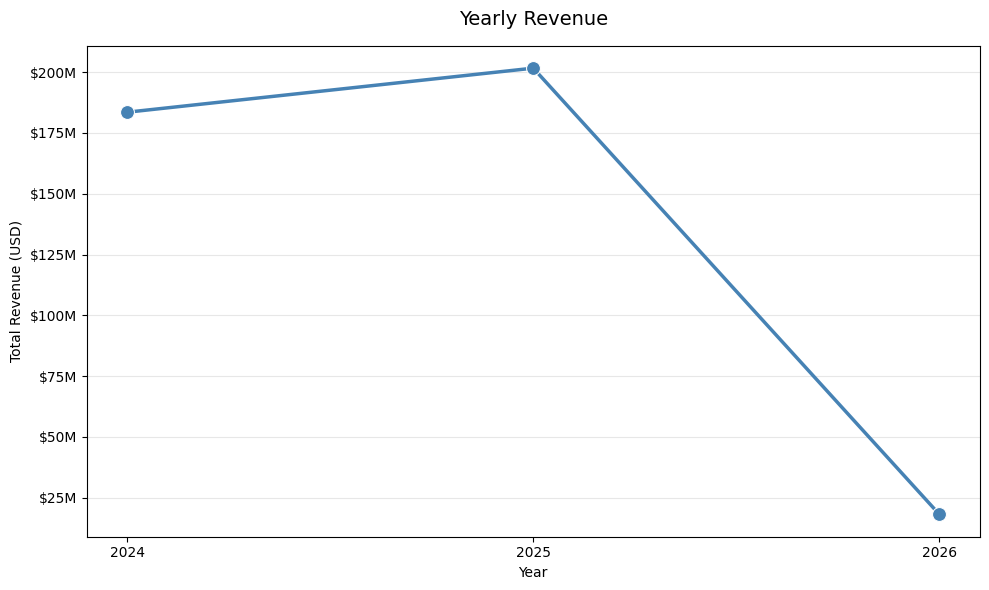

In [155]:
yearly_revenue = (
    sales_df.groupby('order_year')['net_revenue_usd']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=yearly_revenue,
    x='order_year',
    y='net_revenue_usd',
    marker='o',
    markersize=10,
    linewidth=2.5,
    color='steelblue',
)

plt.title('Yearly Revenue', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Total Revenue (USD)')
plt.xticks(yearly_revenue['order_year'])
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 1.2 Revenue by Month

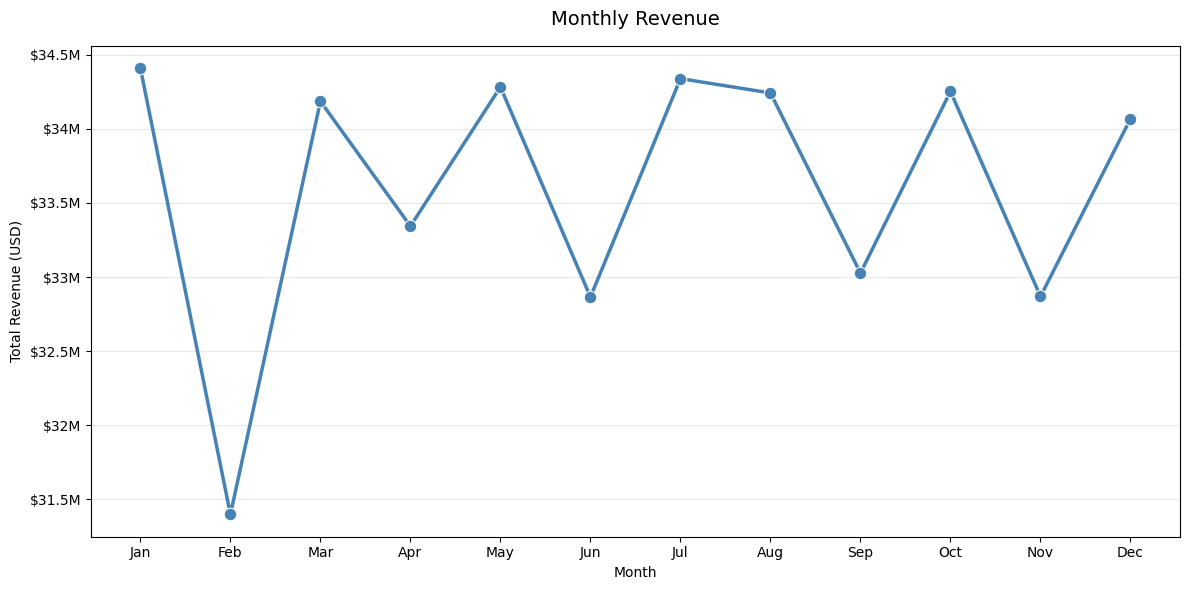

In [156]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_map = {i+1: m for i, m in enumerate(month_order)}

monthly_revenue = (
    sales_df.assign(
        order_month_name=sales_df['order_month'].map(month_map)
    )
    .groupby('order_month_name')['net_revenue_usd']
    .sum()
    .reindex(month_order)
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=monthly_revenue,
    x='order_month_name',
    y='net_revenue_usd',
    marker='o',
    markersize=9,
    linewidth=2.5,
    color='steelblue'
)

plt.title('Monthly Revenue', fontsize=14, pad=15)
plt.xlabel('Month')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 1.3 Revenue by Day of Week

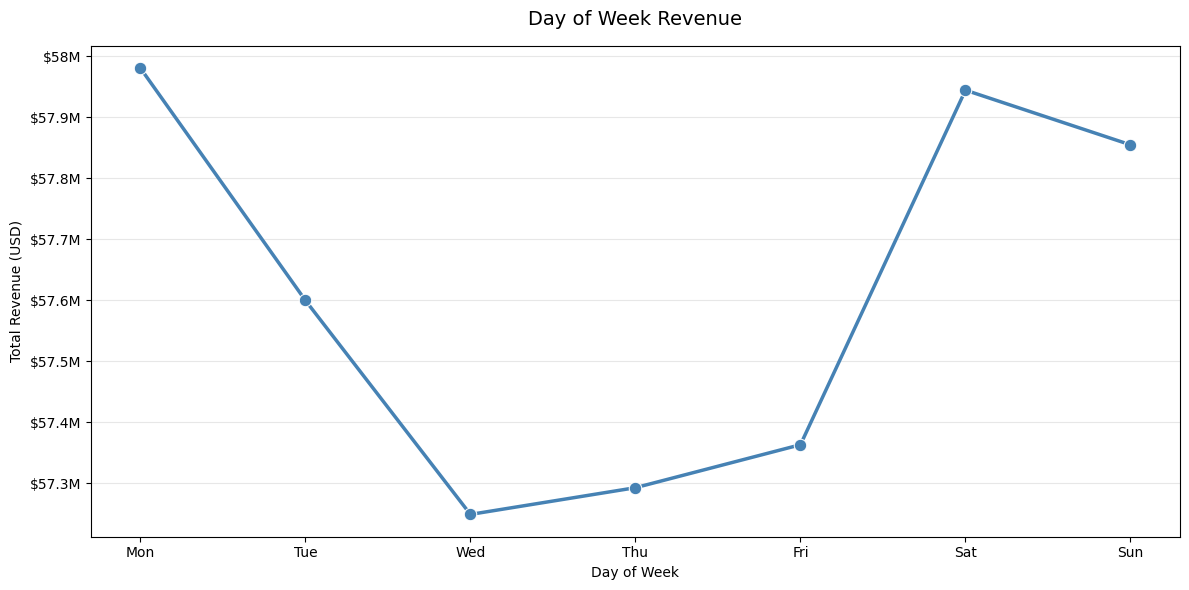

In [157]:
day_of_week_revenue = (
    sales_df.groupby('order_day_of_week')['net_revenue_usd']
    .sum()
    .reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=day_of_week_revenue,
    x='order_day_of_week',
    y='net_revenue_usd',
    marker='o',
    markersize=9,
    linewidth=2.5,
    color='steelblue',
)

plt.title('Day of Week Revenue', fontsize=14, pad=15)
plt.xlabel('Day of Week')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 1.4 Revenue by Part of Day

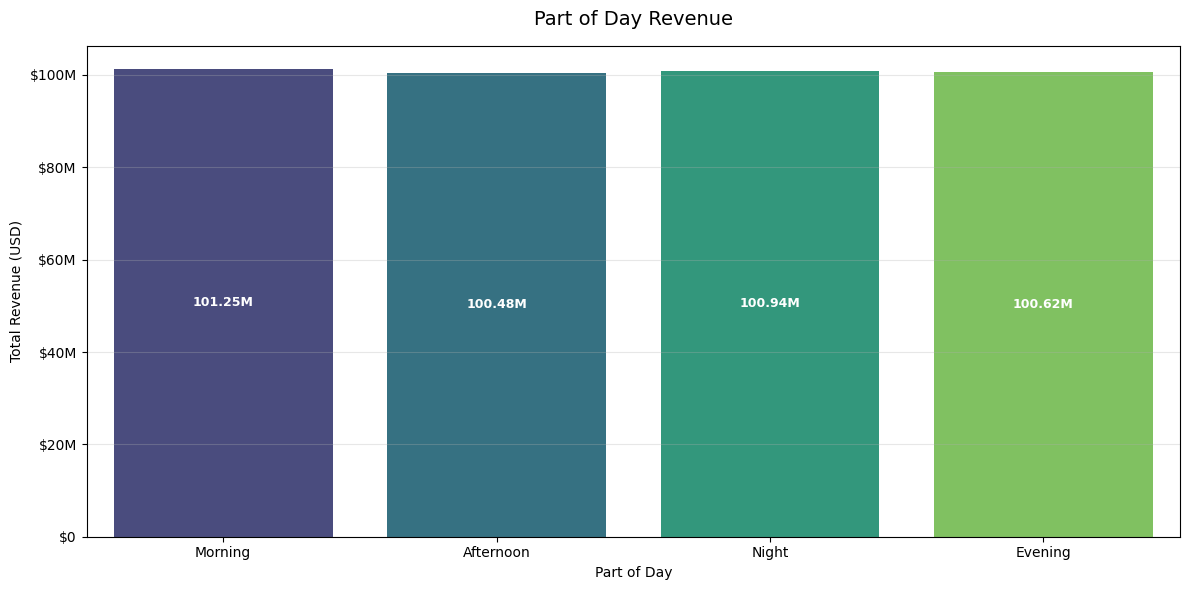

In [158]:

part_day_revenue = (
    sales_df.groupby('part_day')['net_revenue_usd']
    .sum()
    .reindex(['Morning', 'Afternoon', 'Night', 'Evening'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=part_day_revenue,
    x='part_day',
    y='net_revenue_usd',
    palette='viridis',
    hue='part_day',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v/1e6:,.2f}M' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Part of Day Revenue', fontsize=14, pad=15)
plt.xlabel('Part of Day')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 1.5 Revenue: Weekdays vs Weekends

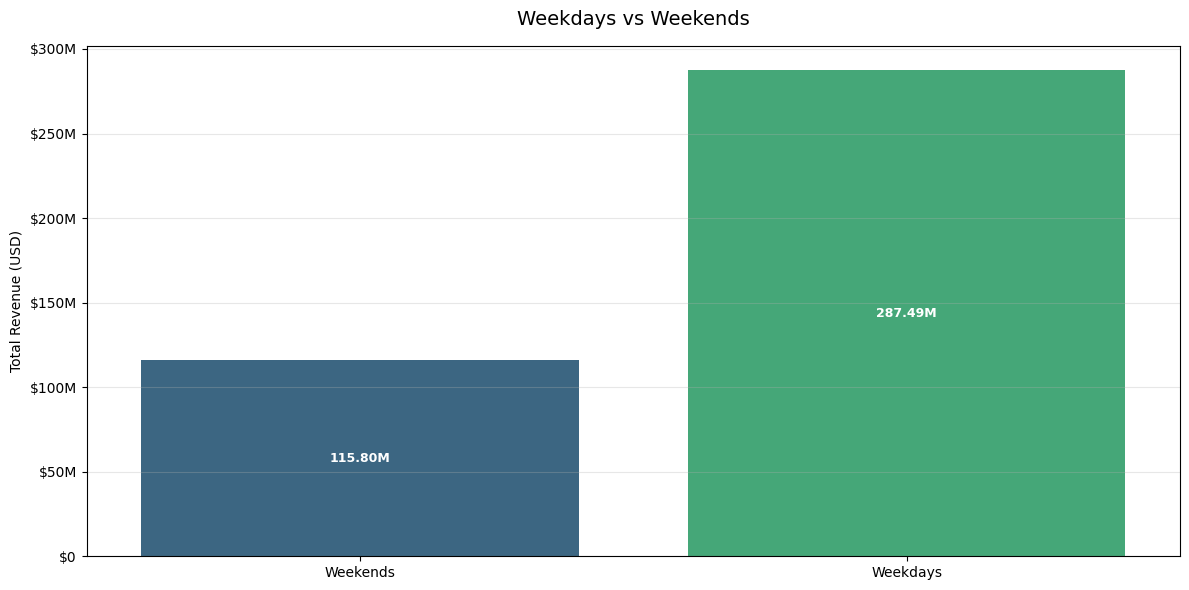

In [159]:
is_weekend_revenue = (
    sales_df.groupby('is_weekend')['net_revenue_usd']
    .sum()
    .reindex(['Yes', 'No'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=is_weekend_revenue,
    x='is_weekend',
    y='net_revenue_usd',
    palette='viridis',
    hue='is_weekend',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v/1e6:,.2f}M' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Weekdays vs Weekends', fontsize=14, pad=15)
plt.xlabel('')
plt.xticks([0, 1], ['Weekends', 'Weekdays'])
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### **Observation and Business Insight**

**1.1 Revenue by Year**  
Revenue increased from 2024 to 2025 by approximately 4–5%. The sharp drop in 2026 is expected, as the year is still incomplete and only partial data is available. Overall, the business shows a positive year-over-year growth trend when comparing full years.

**1.2 Revenue by Month**  
Monthly revenue fluctuates throughout the year. January recorded the highest monthly revenue, followed closely by July. February had the lowest revenue (below $32M), with June also among the weaker months. This suggests possible seasonality, with stronger performance at the beginning of the year and mid-year peaks.

**1.3 Revenue by Day of Week**  
Revenue is relatively higher on Monday and during the weekends. After Monday, revenue gradually declines through the weekdays before rising again toward the weekend. This pattern indicates stronger customer activity at the start of the week and during weekends.

**1.4 Revenue by Part of Day**  
Revenue is fairly balanced across Morning, Afternoon, and Evening, with Morning showing a slight lead. This suggests that purchasing activity is distributed throughout the day, with no extreme concentration in a single time period.

**1.5 Revenue: Weekdays vs Weekends**  
Although individual weekend days perform well, total weekday revenue is higher than total weekend revenue. This is mainly because there are more weekdays than weekend days. In other words, weekends have strong daily performance, but weekdays contribute more to overall revenue due to volume of days.

## 2. Product Sales Performance

### 2.1 Revenue by Category

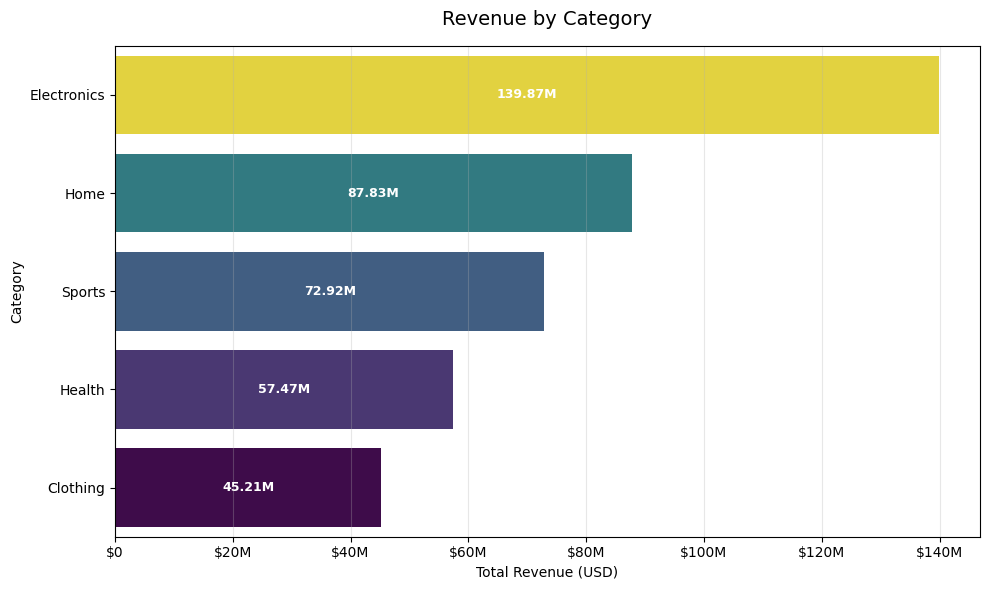

In [160]:

category_revenue = (
    sales_df.groupby('category')['net_revenue_usd']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=category_revenue,
    x='net_revenue_usd',
    y='category',
    palette='viridis',
    orient='h',
    hue='net_revenue_usd',
    legend=False
)


for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v/1e6:,.2f}M' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Revenue by Category', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Category')
plt.gca().xaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 2.2 Top 10 Revenue Sub-Categories

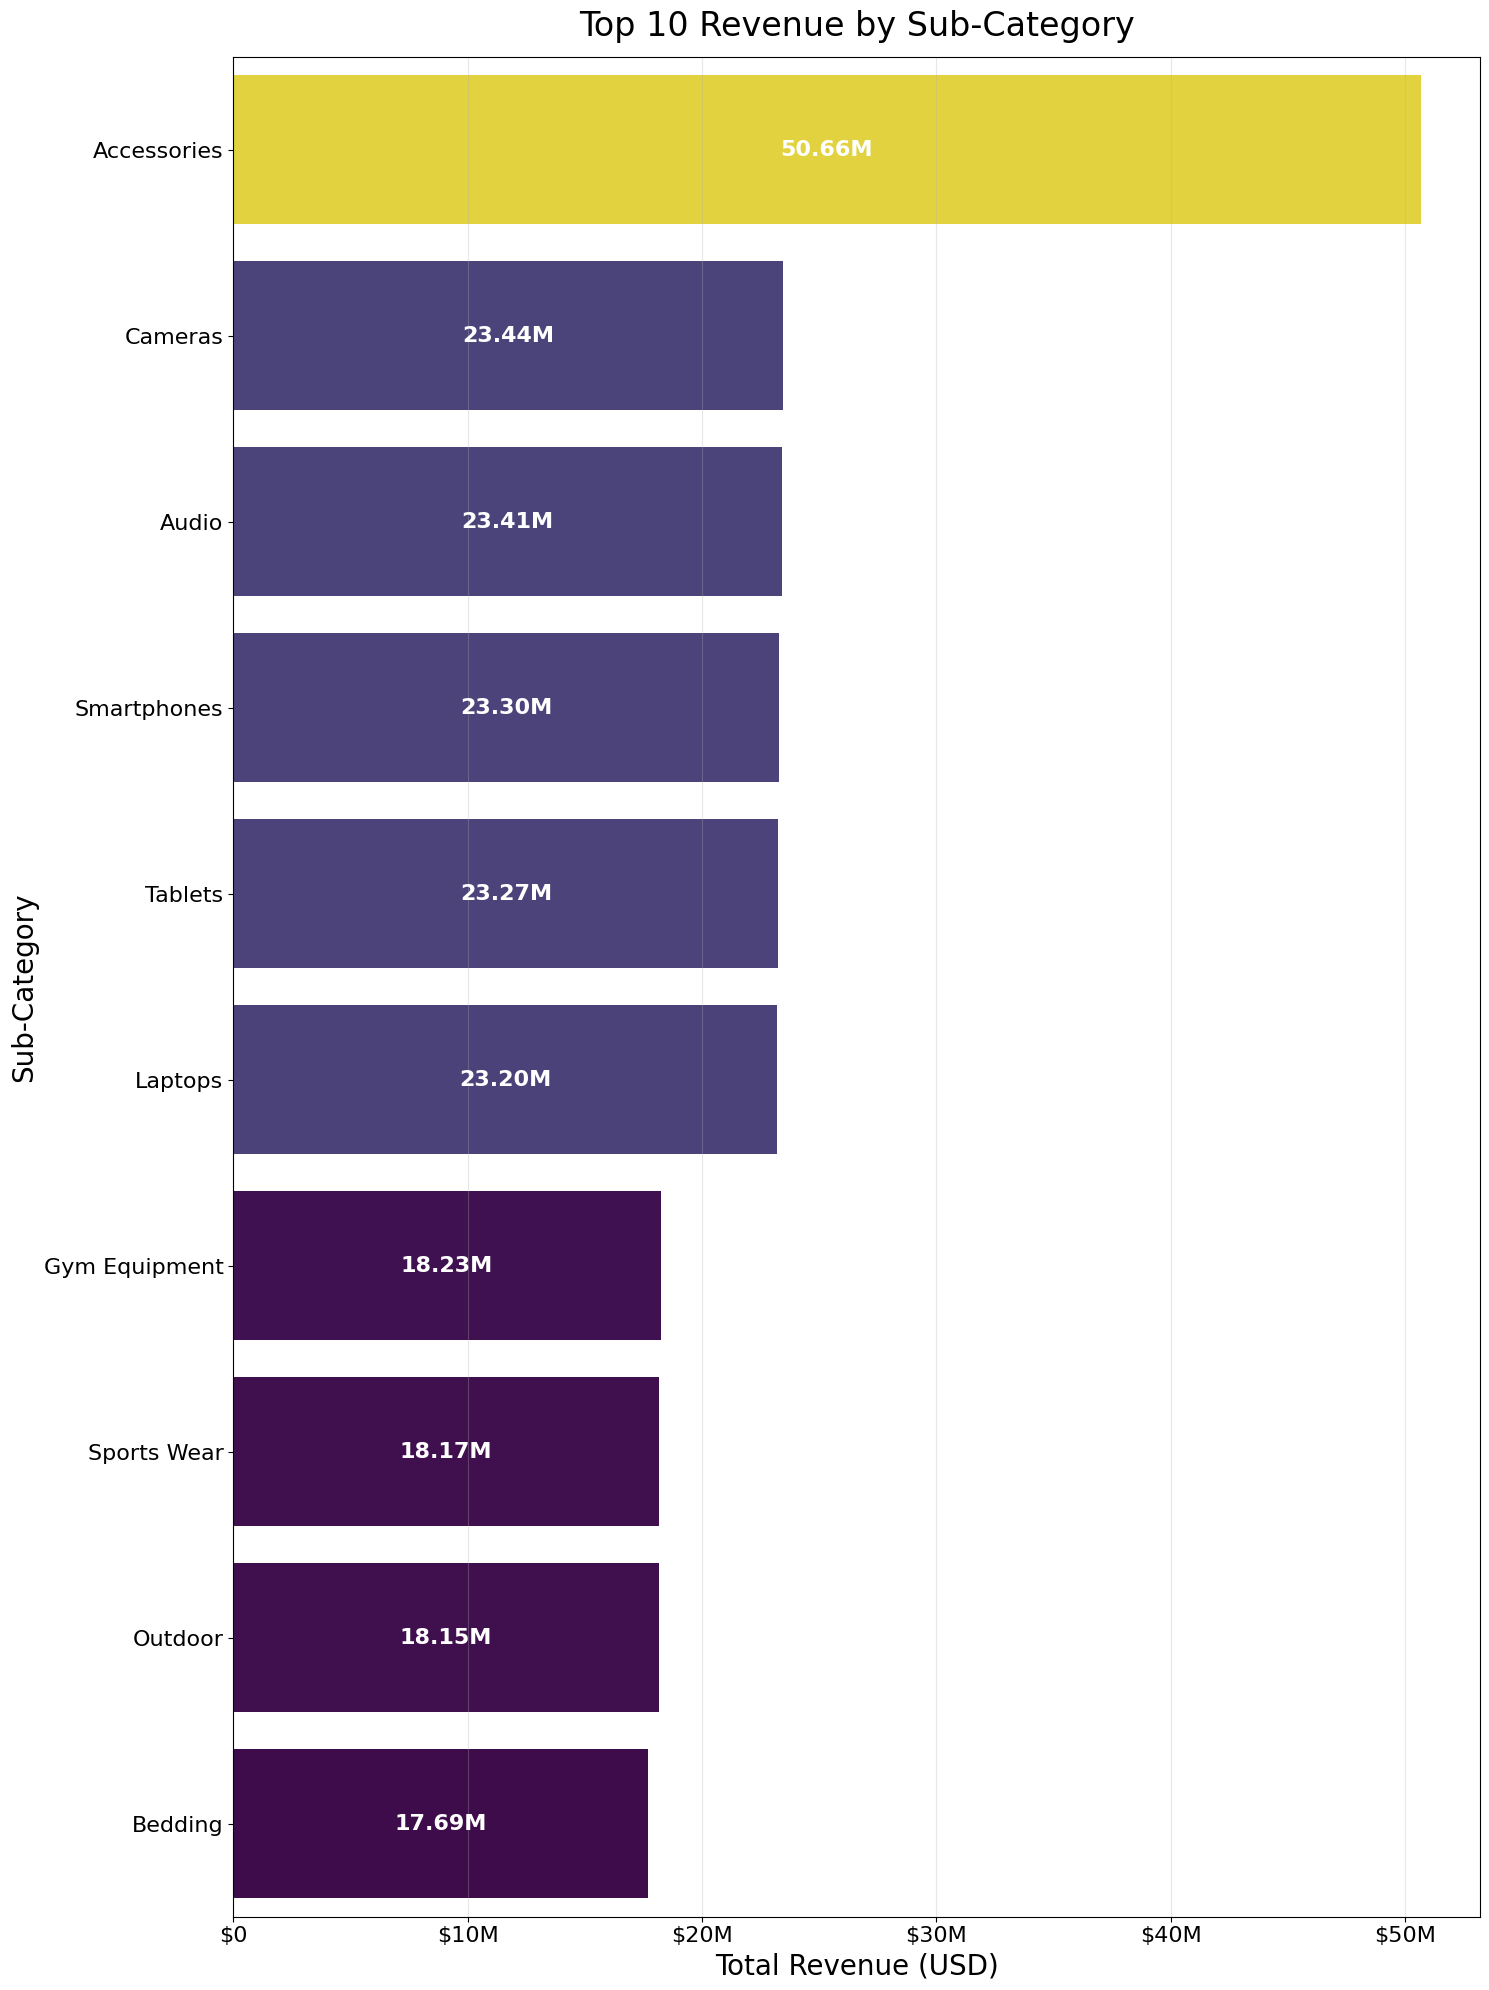

In [161]:
subcategory_revenue = (
    sales_df.groupby('sub_category')['net_revenue_usd']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(15, 20))

ax = sns.barplot(
    data=subcategory_revenue,
    x='net_revenue_usd',
    y='sub_category',
    palette='viridis',
    orient='h',
    hue='net_revenue_usd',
    legend=False
)


for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v/1e6:,.2f}M' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=16,
        fontweight='bold'
    )
    

plt.title('Top 10 Revenue by Sub-Category', fontsize=24, pad=15)
plt.xlabel('Total Revenue (USD)', fontsize=20)
plt.ylabel('Sub-Category', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.gca().xaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 2.3 Average Unit Price by Category and Price Tier

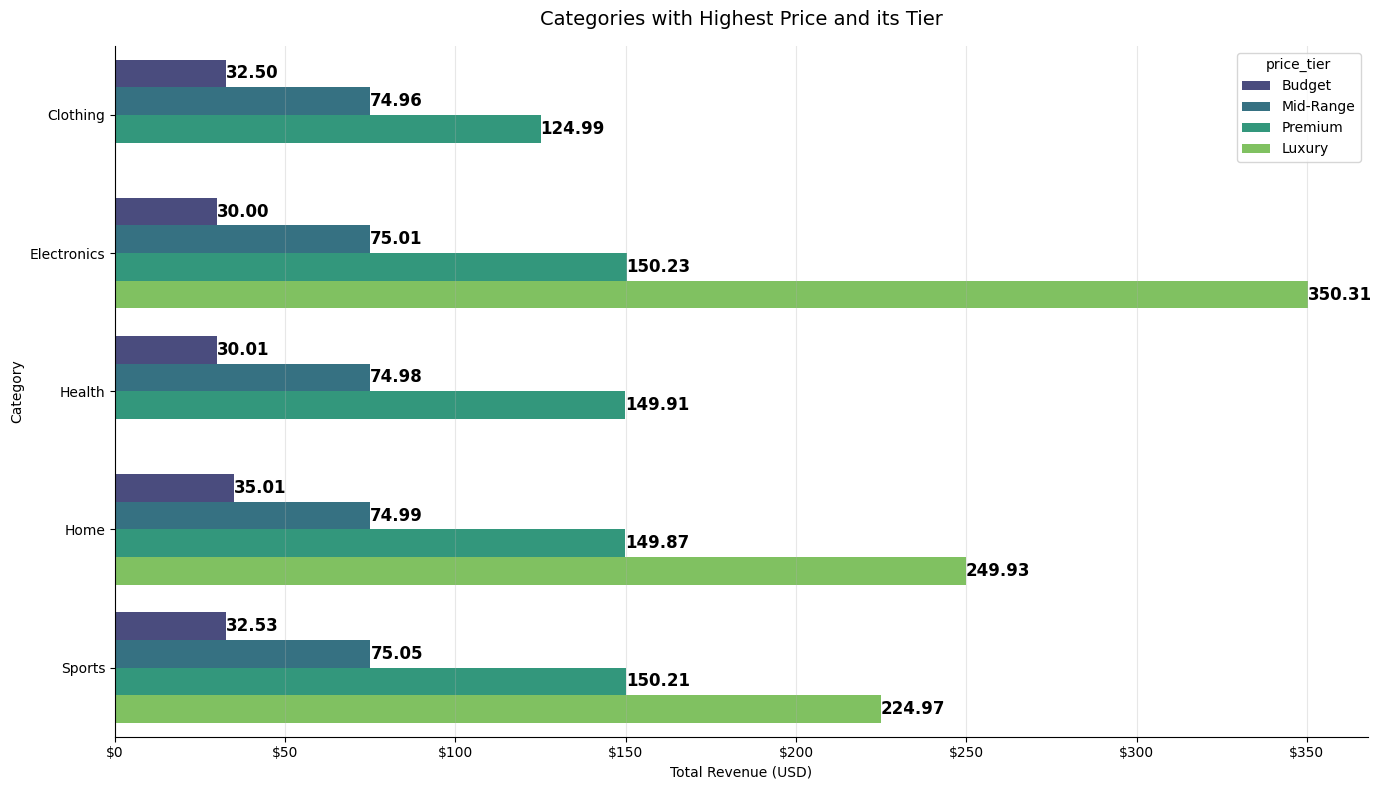

In [162]:

price_category = (
    sales_df
    .groupby(['category', 'price_tier'])['unit_price_usd']
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=price_category,
    x='unit_price_usd',
    y='category',
    hue='price_tier',
    palette='viridis',
    orient='h'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.2f}' for v in container.datavalues],
        label_type='edge',          
        color='black',
        fontsize=12,
        fontweight='bold'
    )

plt.title('Categories with Highest Price and its Tier', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Category')
plt.gca().xaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 2.4 Total Quantity Sold by Category

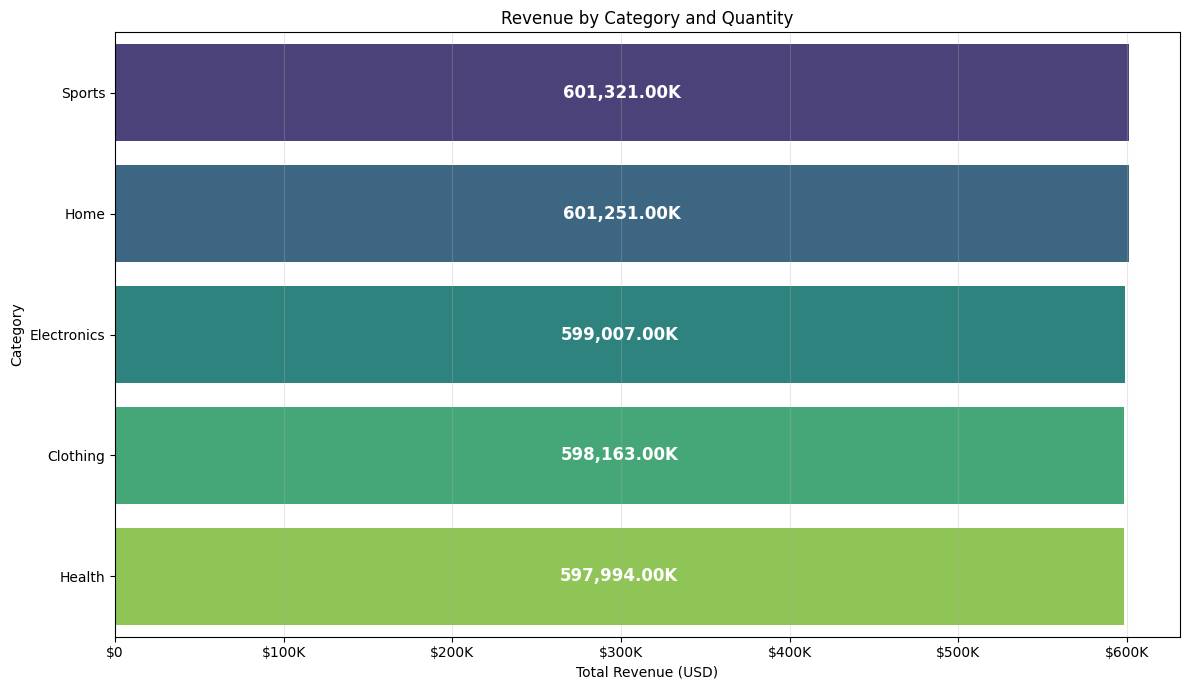

In [163]:
quantity_category = (
    sales_df
    .groupby('category')['quantity']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=quantity_category,
    x='quantity',
    y='category',
    palette='viridis',
    hue='category',
    legend=False,
    orient='h',
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.2f}K' for v in container.datavalues],
        label_type='center',
        color='white',
        fontsize=12,
        fontweight='bold'
    )

plt.title('Revenue by Category and Quantity')
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Category')
plt.gca().xaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

#### **Observation and Business Insight**

**2.1 Revenue by Category**  
Electronics generated the highest revenue among all categories (nearly $140M), while the other categories each contributed less than $90M. This shows that Electronics is the main revenue driver of the business.

**2.2 Top 10 Revenue by Sub-Category**  
Accessories recorded the highest revenue among sub-categories at approximately $50M, creating a wide gap from the rest (most of which generated less than $25M). This supports the strong performance of the Electronics category, as accessories are commonly purchased together with electronic products.

**2.3 Average Unit Price by Category and Price Tier**  
Budget and Mid-Range average prices are relatively consistent across categories (around $30–$35 and ~$75 respectively).  

The biggest difference appears in the higher tiers:
- Electronics has the highest Luxury average price (~$350), clearly above other categories.
- Home and Sports also reach relatively high Luxury prices (~$225–$250).
- Clothing remains more moderate in the Premium/Luxury range.

This indicates that Electronics has a broader and more premium price spectrum.

**2.4 Quantity / Purchase Volume by Category**  
The total quantity purchased is relatively high and balanced across all categories. This means customers are still buying actively in every category.  

However, Electronics still leads in revenue because it has more items in the higher price tiers (especially Luxury). In other words, while purchase volume is spread across categories, Electronics generates more revenue due to higher unit prices rather than just higher quantity alone.

## 3. Geographic Sales Performance

### 3.1 Revenue by Country

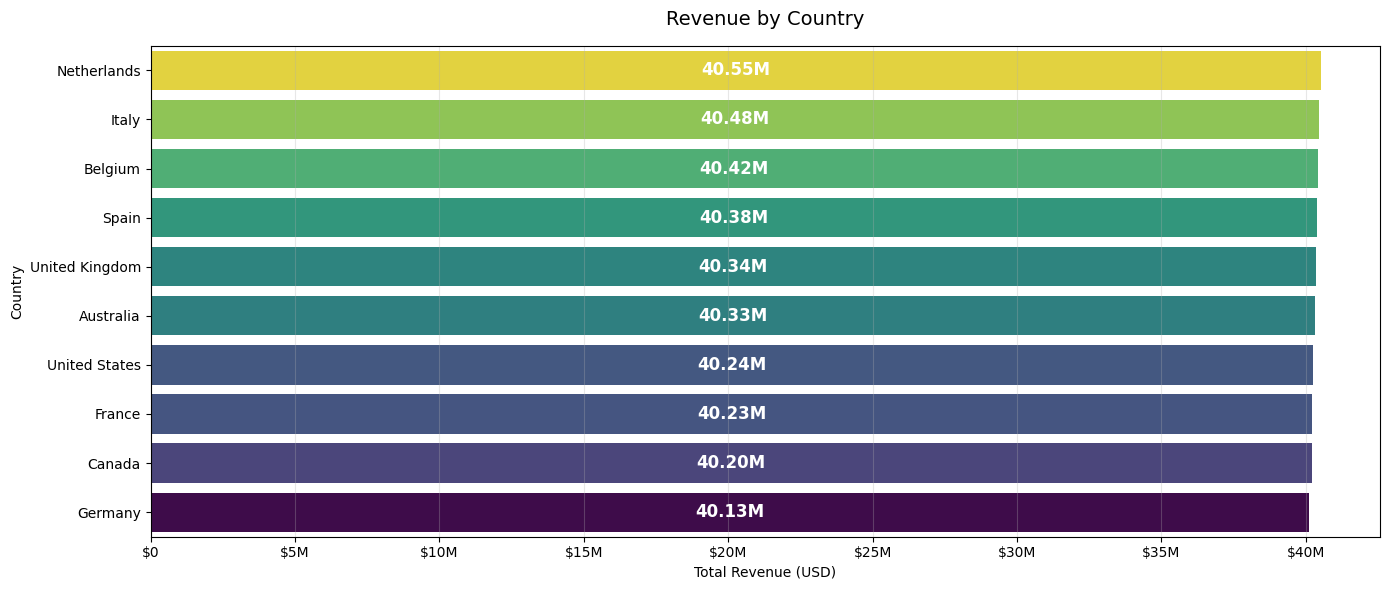

In [164]:
country_revenue = (
    sales_df.groupby('country')['net_revenue_usd']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=country_revenue,
    x='net_revenue_usd',
    y='country',
    orient='h',
    palette='viridis',
    hue='net_revenue_usd',
    legend=False
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v/1e6:,.2f}M' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=12,
        fontweight='bold',
    )

plt.title('Revenue by Country', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Country')
plt.gca().xaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2 Revenue by Country Across Years

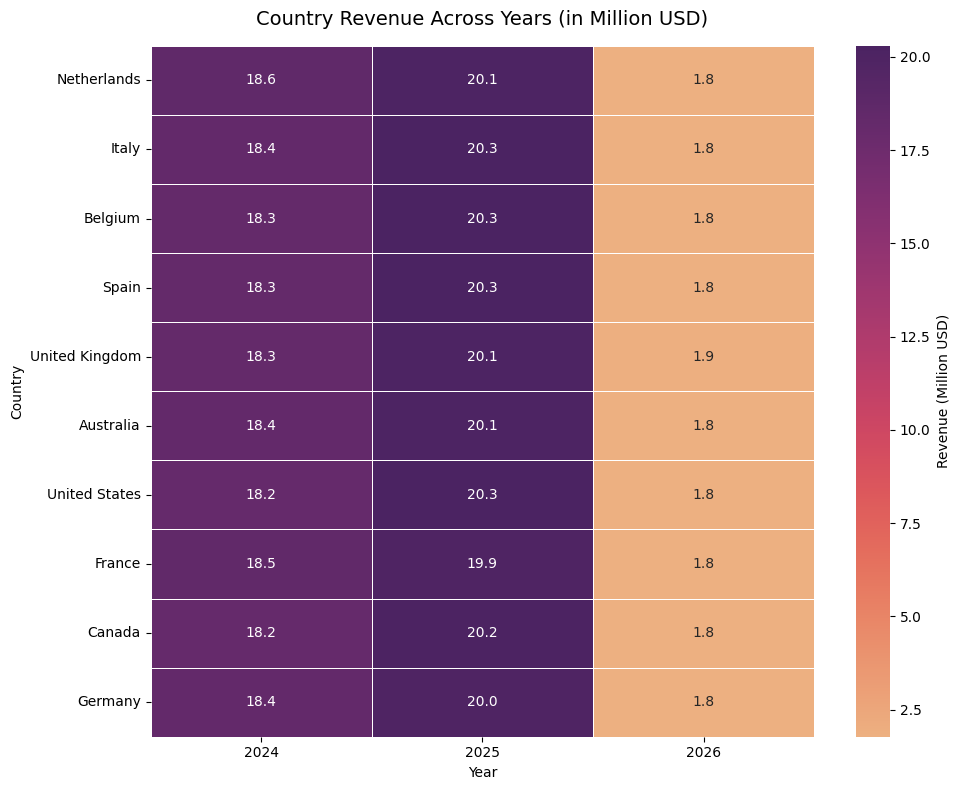

In [165]:
# Prepare data
country_yearly = (
    sales_df.groupby(['country', 'order_year'])['net_revenue_usd']
    .sum()
    .unstack(fill_value=0)          # years become columns
)

# Optional: sort by total revenue
country_yearly = country_yearly.loc[
    country_yearly.sum(axis=1).sort_values(ascending=False).index
]

plt.figure(figsize=(10, 8))
sns.heatmap(
    country_yearly / 1e6,           # show in millions
    annot=True,
    fmt='.1f',
    cmap='flare',
    linewidths=0.5,
    cbar_kws={'label': 'Revenue (Million USD)'}
)

plt.title('Country Revenue Across Years (in Million USD)', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

#### **Observation and Business Insight**

**3.1 Revenue by Country**  
Revenue is very evenly distributed across the 10 countries. Netherlands recorded the highest total revenue at approximately $40.5M, followed closely by Italy and the other countries. All countries generated roughly $40M or higher in total, with only minimal differences between them. This indicates a well-balanced geographic performance with no single country heavily dominating overall revenue.

**3.2 Revenue by Country Across Years**  
Looking at the yearly breakdown:
- In **2024**, all countries generated between $18.2M and $18.6M.
- In **2025**, revenue increased slightly across the board to around $19.9M–$20.3M.
- In **2026**, values drop sharply to about $1.8M–$1.9M because the year is still incomplete.

The heatmap shows a highly consistent pattern: every country follows almost the same revenue level each year, with only very small variations. There is a clear and uniform growth from 2024 to 2025 across all markets, while 2026 remains partial and not yet comparable.

## 4. Order Value Analysis

### 4.1 Revenue by Order Value Segment

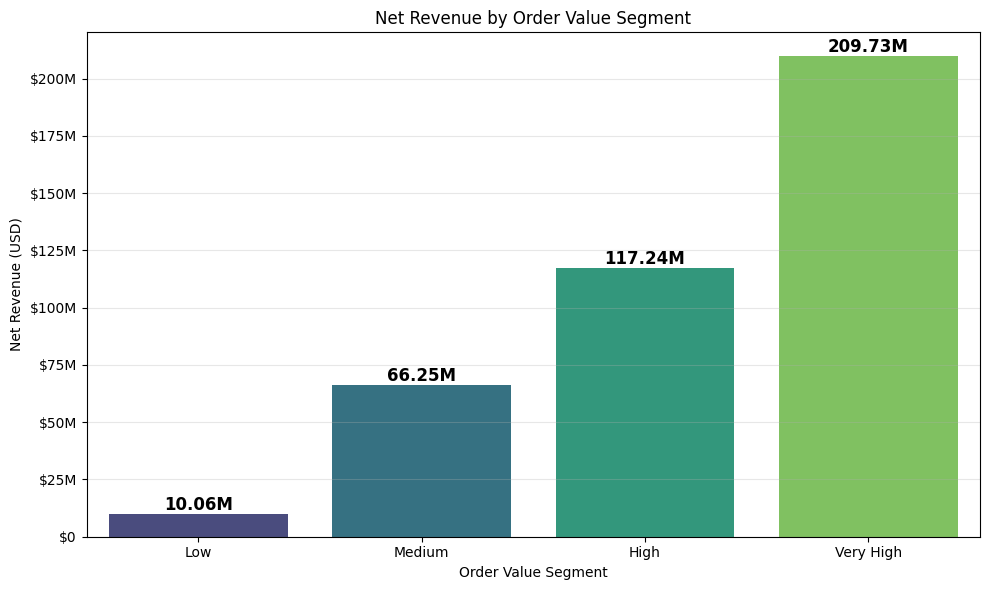

In [166]:
order_value_revenue = (
    sales_df
    .groupby('order_value_segment')['net_revenue_usd']
    .sum()
    .reset_index()
)

order_value_revenue['order_value_segment'] = pd.Categorical(
    order_value_revenue['order_value_segment'],
    categories=['Low', 'Medium', 'High', 'Very High'],
    ordered=True
)

order_value_revenue = order_value_revenue.sort_values('order_value_segment')

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=order_value_revenue,
    x='order_value_segment',
    y='net_revenue_usd',
    palette='viridis',
    hue='order_value_segment',
    legend=False
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v/1e6:,.2f}M' for v in container.datavalues],
        label_type='edge',          
        color='black',
        fontsize=12,
        fontweight='bold'
    )

plt.title('Net Revenue by Order Value Segment')
plt.xlabel('Order Value Segment')
plt.ylabel('Net Revenue (USD)')
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2 Order Value Segment Revenue Across Categories

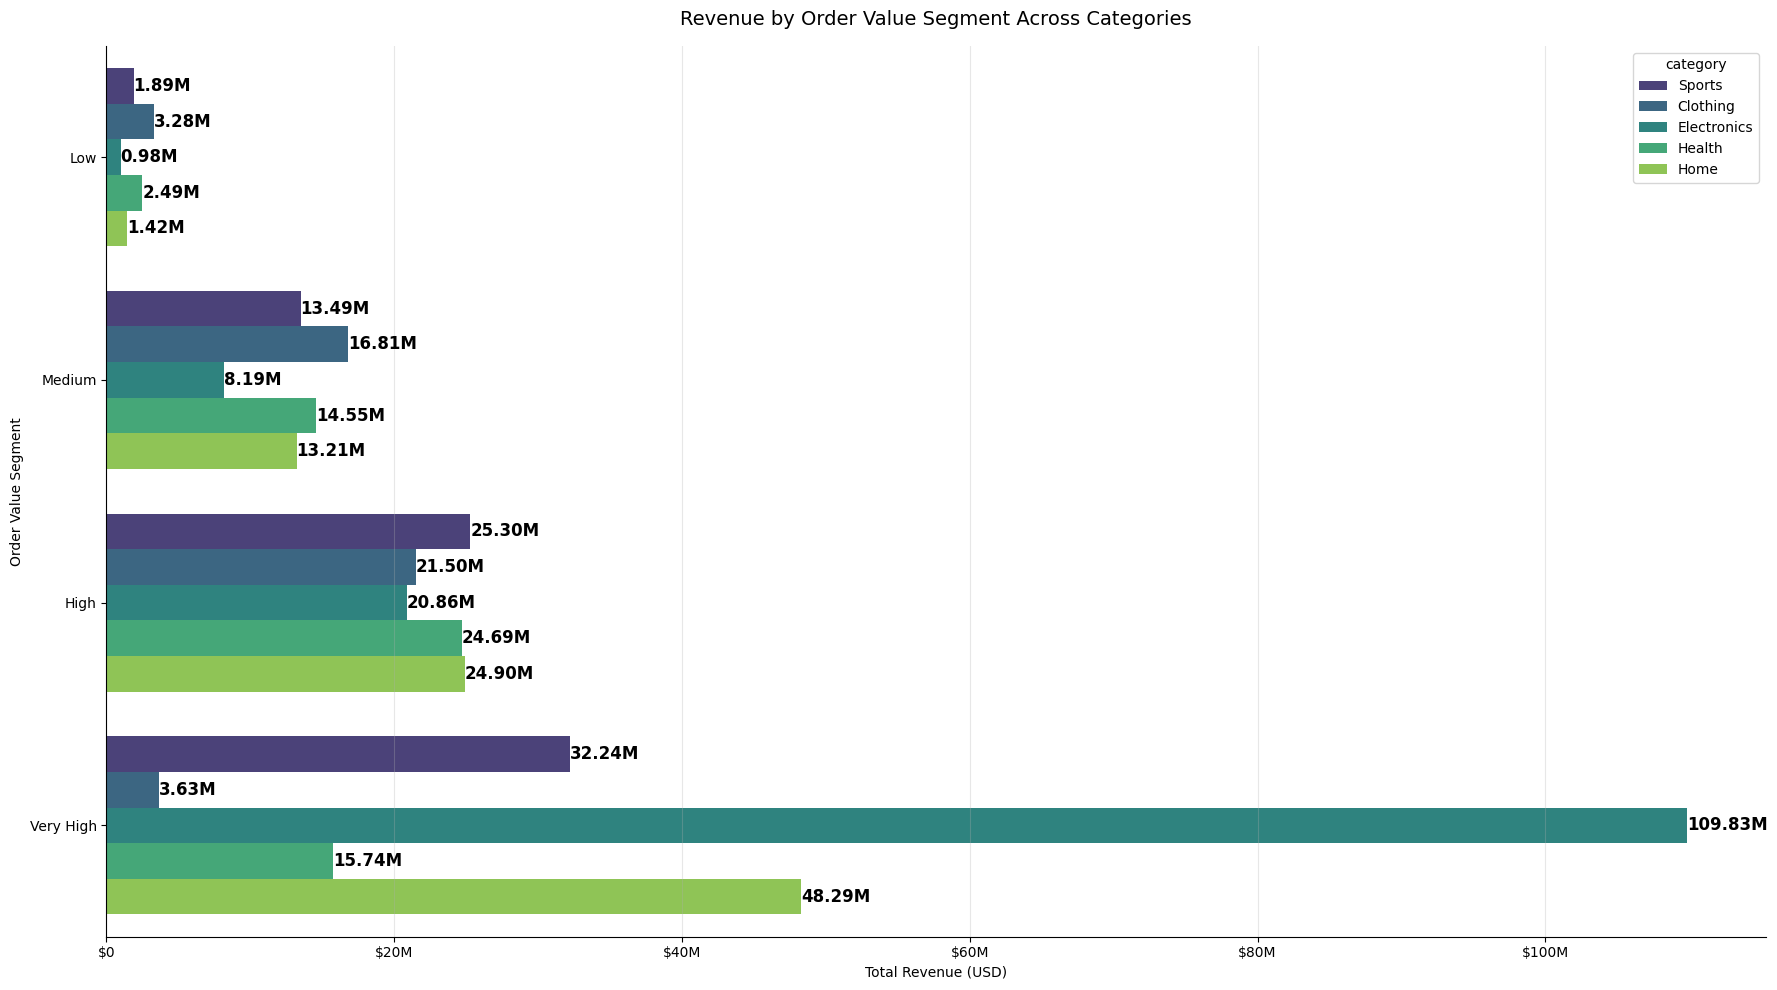

In [167]:
order_value_segment_revenue = (
    sales_df
    .groupby(['order_value_segment', 'category'])['net_revenue_usd']
    .sum()
    .reset_index()
)

order_value_segment_revenue['order_value_segment'] = pd.Categorical(
    order_value_segment_revenue['order_value_segment'],
    categories=['Low', 'Medium', 'High', 'Very High'],
    ordered=True
)

order_value_segment_revenue = order_value_segment_revenue.sort_values('order_value_segment')

plt.figure(figsize=(18, 10))

ax = sns.barplot(
    data=order_value_segment_revenue,
    x='net_revenue_usd',
    y='order_value_segment',
    hue='category',
    palette='viridis',
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v/1e6:,.2f}M' for v in container.datavalues],
        label_type='edge',          
        color='black',
        fontsize=12,
        fontweight='bold'
    )
    
plt.title('Revenue by Order Value Segment Across Categories', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel("Order Value Segment")
plt.gca().xaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

#### **Observation and Business Insight**

**4.1 Revenue by Order Value Segment**  
Revenue is heavily concentrated in higher order value segments.  
- Very High orders generated the largest share at **$209.73M**  
- High orders followed with **$117.24M**  
- Medium contributed **$66.25M**  
- Low orders accounted for only **$10.06M**

This shows that a large portion of total revenue comes from high-value transactions rather than many small orders. The business benefits significantly from customers who place larger orders.

**4.2 Order Value Segment Revenue Across Categories**  
The distribution changes depending on the segment:

- In **Low** and **Medium** segments, revenue is relatively spread across categories.
- In the **High** segment, contributions remain fairly balanced among Sports, Clothing, Electronics, Health, and Home.
- In the **Very High** segment, **Electronics dominates strongly** with **$109.83M**, followed by Home ($48.29M) and Sports ($32.24M). Clothing contributes very little ($3.63M) in this segment.

This indicates that Electronics is the main driver of high-value orders, while other categories participate more evenly in lower-to-mid order values.

## 5. Sales Analysis by Customer Attributes

### 5.1 Customer Segment Value Counts (%)


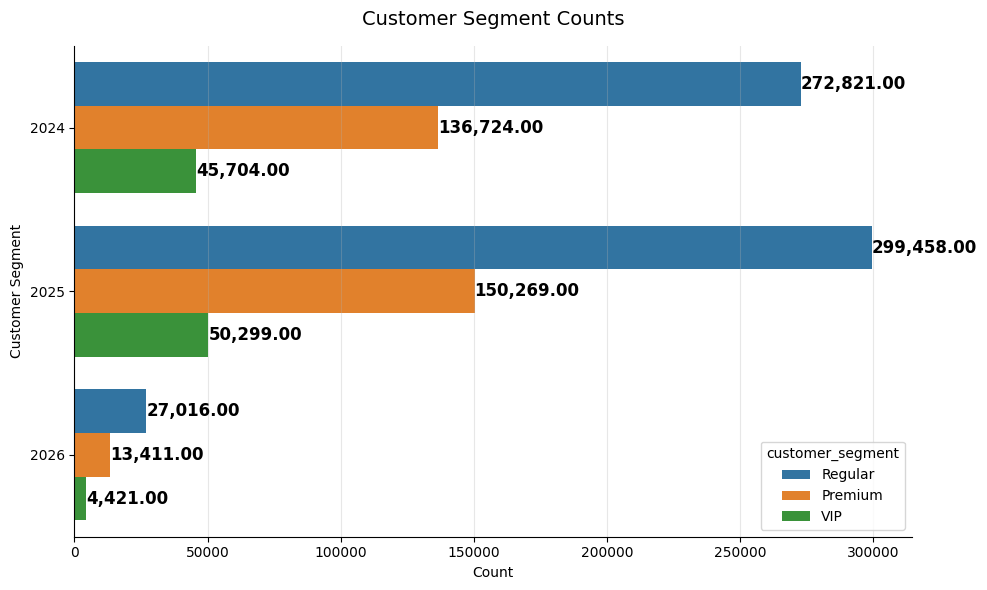

In [168]:

customer_segment_counts = (
    sales_df
    .groupby('order_year')['customer_segment']
    .value_counts()
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=customer_segment_counts,
    x='count',
    y='order_year',
    hue='customer_segment',
    orient='h'
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.2f}' for v in container.datavalues],
        label_type='edge',          
        color='black',
        fontsize=12,
        fontweight='bold'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title('Customer Segment Counts', fontsize=14, pad=15)
plt.xlabel('Count')
plt.ylabel("Customer Segment")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.2 Revenue Contribution by Customer Segment (%)

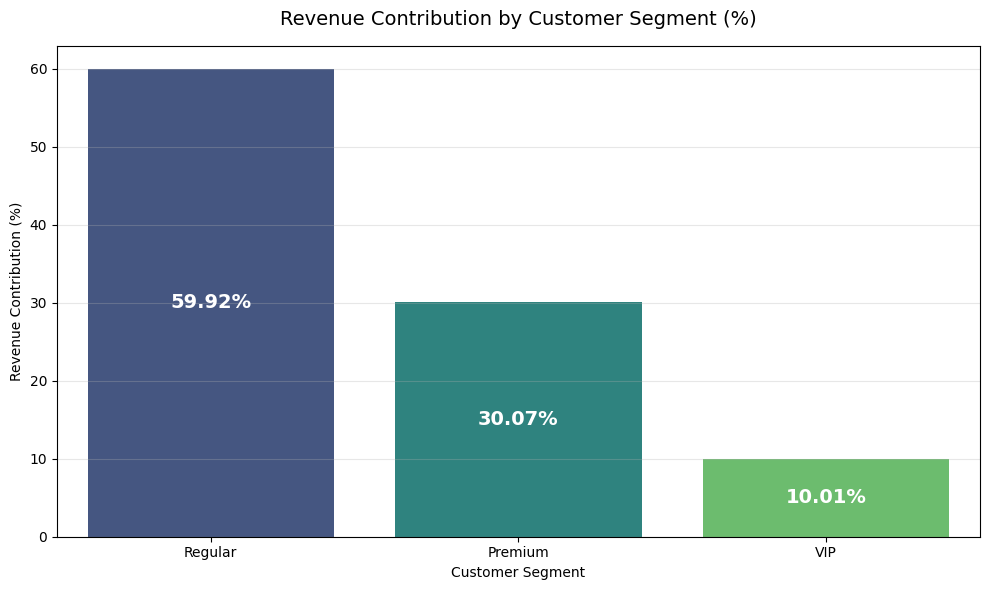

In [169]:
customer_segment_revenue = sales_df.groupby('customer_segment')['net_revenue_usd'].sum().reset_index().sort_values('net_revenue_usd', ascending=False).head(15)

total_revenue = customer_segment_revenue['net_revenue_usd'].sum()
customer_segment_revenue['revenue_pct'] = (customer_segment_revenue['net_revenue_usd'] / total_revenue) * 100

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=customer_segment_revenue,
    x='customer_segment',
    y='revenue_pct',
    hue='customer_segment',
    legend=False,
    palette='viridis'
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.2f}%' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=14,
        fontweight='bold'
    )
    
plt.title('Revenue Contribution by Customer Segment (%)', fontsize=14, pad=15)
plt.xlabel('Customer Segment')
plt.ylabel("Revenue Contribution (%)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3 Revenue Contribution by Age Group (%)

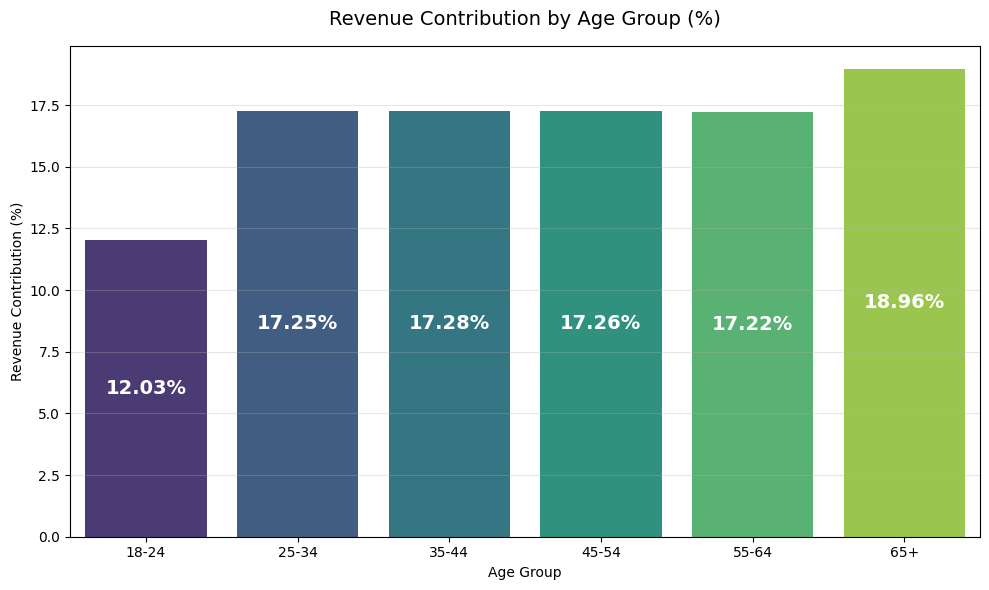

In [170]:
age_group_revenue = (
    sales_df
    .groupby('age_group')['net_revenue_usd']
    .sum()
    .reindex(['18-24', '25-34', '35-44', '45-54', '55-64', '65+'])
    .reset_index()
    .head(15)
)

total_revenue = age_group_revenue['net_revenue_usd'].sum()
age_group_revenue['revenue_pct'] = (age_group_revenue['net_revenue_usd'] / total_revenue) * 100

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=age_group_revenue,
    x='age_group',
    y='revenue_pct',
    hue='age_group',
    legend=False,
    palette='viridis'
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.2f}%' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=14,
        fontweight='bold'
    )
    
plt.title('Revenue Contribution by Age Group (%)', fontsize=14, pad=15)
plt.xlabel('Age Group')
plt.ylabel("Revenue Contribution (%)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4 Revenue Contribution by Gender (%)

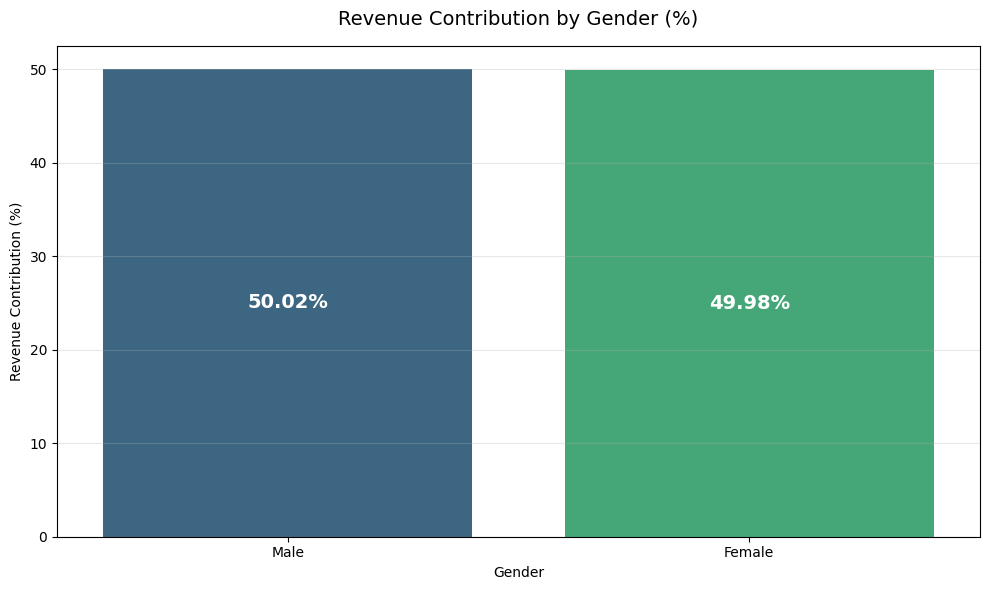

In [171]:
gender_revenue = (
    sales_df
    .groupby('gender')['net_revenue_usd']
    .sum()
    .reindex(['Male', 'Female'])
    .reset_index()
    .head(15)
)

total_revenue = gender_revenue['net_revenue_usd'].sum()
gender_revenue['revenue_pct'] = (gender_revenue['net_revenue_usd'] / total_revenue) * 100

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=gender_revenue,
    x='gender',
    y='revenue_pct',
    hue='gender',
    legend=False,
    palette='viridis'
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.2f}%' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=14,
        fontweight='bold'
    )
    
plt.title('Revenue Contribution by Gender (%)', fontsize=14, pad=15)
plt.xlabel('Gender')
plt.ylabel("Revenue Contribution (%)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.5 Average Order Value by Customer Segment

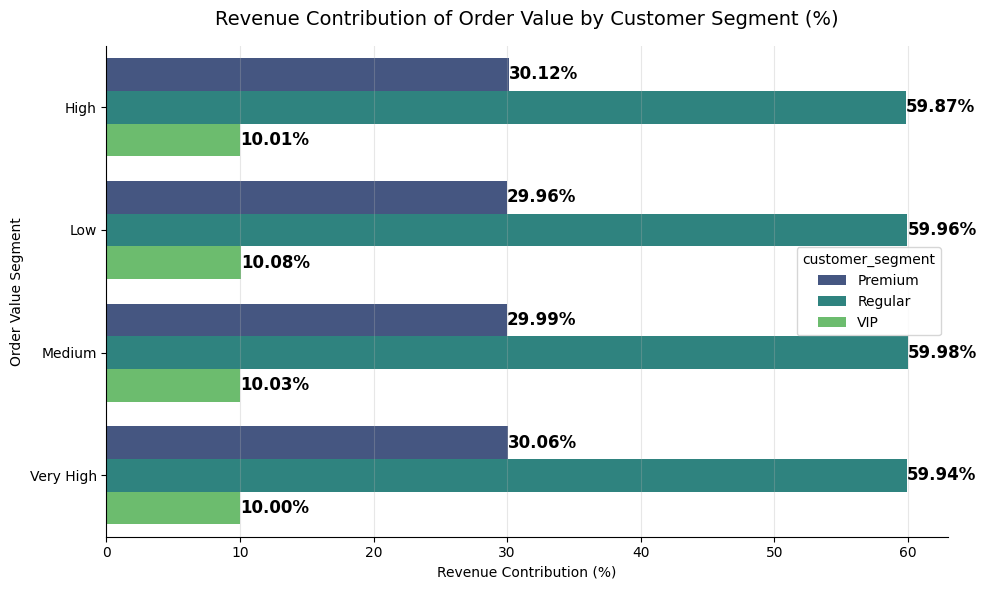

In [172]:
order_value_by_customer_segment = (
    sales_df
    .groupby(['customer_segment', 'order_value_segment'])['net_revenue_usd']
    .sum()
    .reset_index()
)

order_value_by_customer_segment['revenue_pct'] = (
    order_value_by_customer_segment
    .groupby(['order_value_segment'])['net_revenue_usd']
    .transform(lambda x: (x / x.sum()) * 100)
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=order_value_by_customer_segment,
    x='revenue_pct',
    y='order_value_segment',
    hue='customer_segment',
    palette='viridis',
    orient='h'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.2f}%' for v in container.datavalues],
        label_type='edge',          
        color='black',
        fontsize=12,
        fontweight='bold'
    )
    
plt.title('Revenue Contribution of Order Value by Customer Segment (%)', fontsize=14, pad=15)
plt.xlabel('Revenue Contribution (%)')
plt.ylabel("Order Value Segment")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

#### **Business Insight and Observation**

**5.1 Customer Segment Value Counts**  


**5.1 Revenue Contribution by Customer Segment in Percent**  
Data shows that regular customers were the highest revenue contributor with almost 60%, while Premium has 30%, and VIP customers with only 10%. Which means that Regular customer has 
  
**5.2 Revenue Contribution by Age Group in Percent**  

  
**5.3 Revenue Contribution by Gender in Percent**  

  

**5.4 Average Order Value by Customer Segment**  


## 6. Profitability Analysis

### 6.1 Profit by Category Across Year

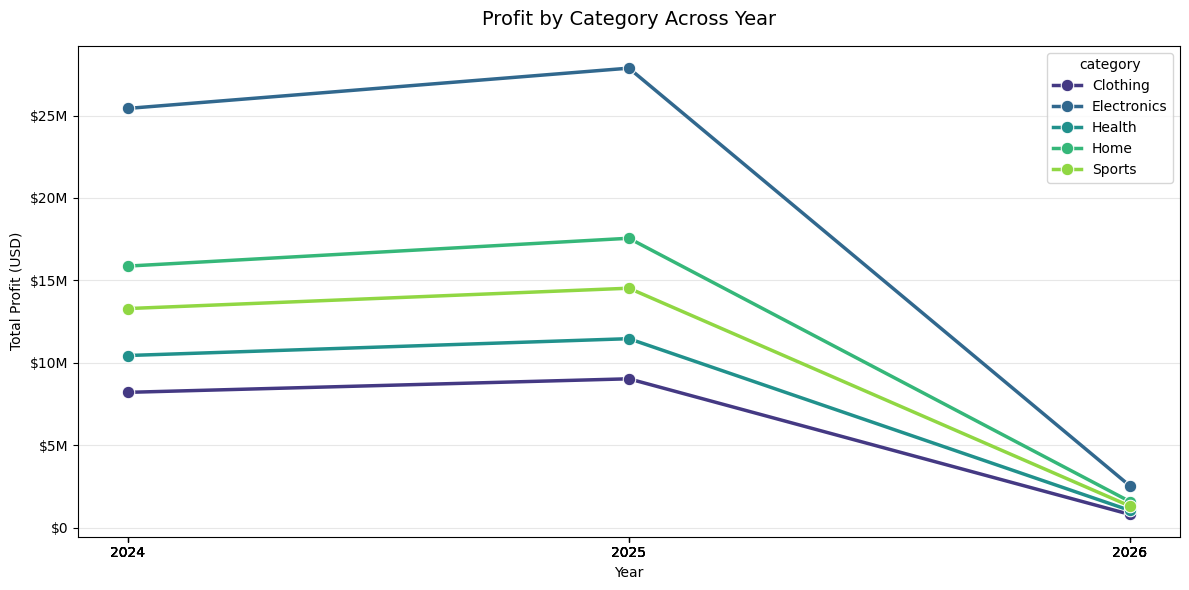

In [173]:
category_profit = (
    sales_df
    .groupby(['order_year', 'category'])['profit_usd']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=category_profit,
    x='order_year',
    y='profit_usd',
    marker='o',
    markersize=9,
    linewidth=2.5,
    palette='viridis',
    hue='category'
)

plt.title('Profit by Category Across Year', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Total Profit (USD)')
plt.xticks(category_profit['order_year'])
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



### 6.2 Profit Margin by Category Across Year

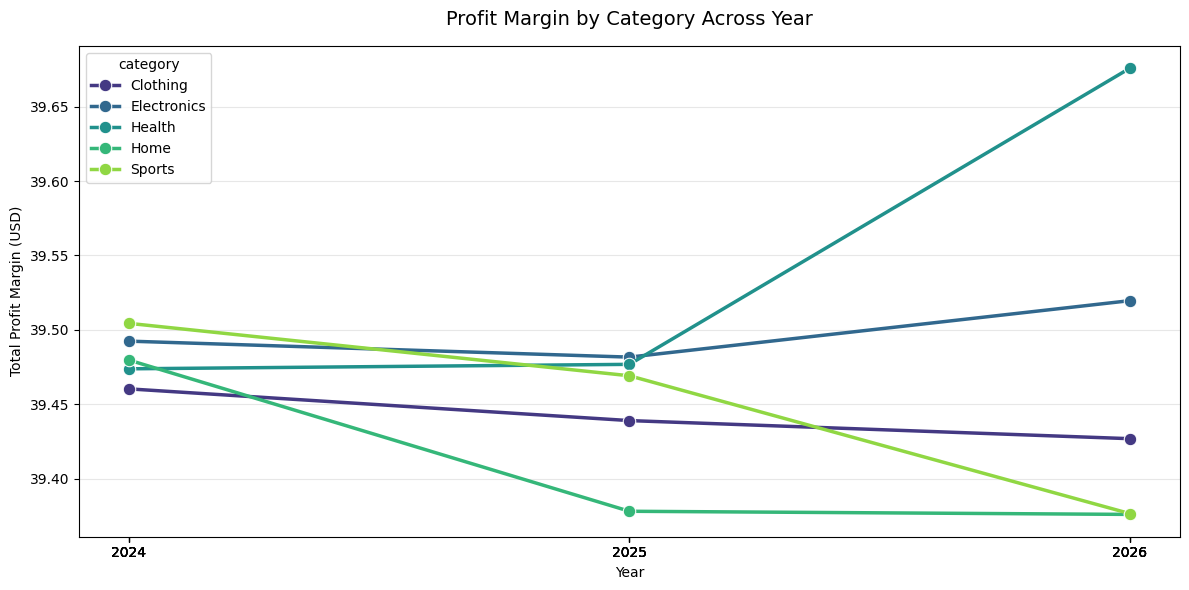

In [174]:
category_profit_margin = (
    sales_df
    .groupby(['order_year', 'category'])['profit_margin_percent']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=category_profit_margin,
    x='order_year',
    y='profit_margin_percent',
    marker='o',
    markersize=9,
    linewidth=2.5,
    palette='viridis',
    hue='category'
)

plt.title('Profit Margin by Category Across Year', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Total Profit Margin (USD)')
plt.xticks(category_profit_margin['order_year'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



### 6.3 Profit by Country Across Year

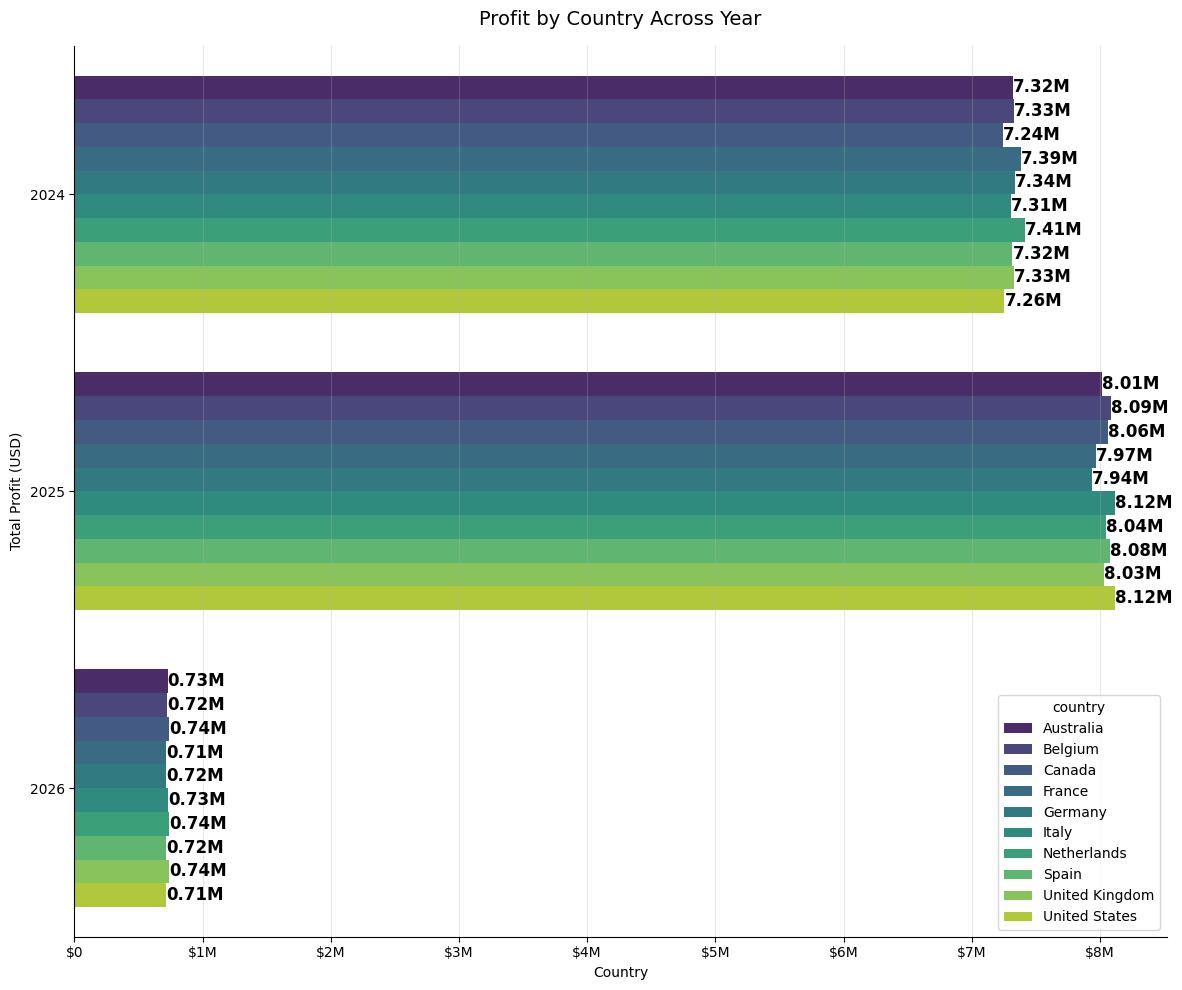

In [175]:
profit_country = (
    sales_df
    .groupby(['order_year', 'country'])['profit_usd']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 10))

ax = sns.barplot(
    data=profit_country,
    x='profit_usd',
    y='order_year',
    palette='viridis',
    hue='country',
    orient='h'
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v/1e6:,.2f}M' for v in container.datavalues],
        label_type='edge',          
        color='black',
        fontsize=12,
        fontweight='bold'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title('Profit by Country Across Year', fontsize=14, pad=15)
plt.xlabel('Country')
plt.ylabel('Total Profit (USD)')
plt.gca().xaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()



### 6.4 Net Revenue vs Profit by Category Across Year

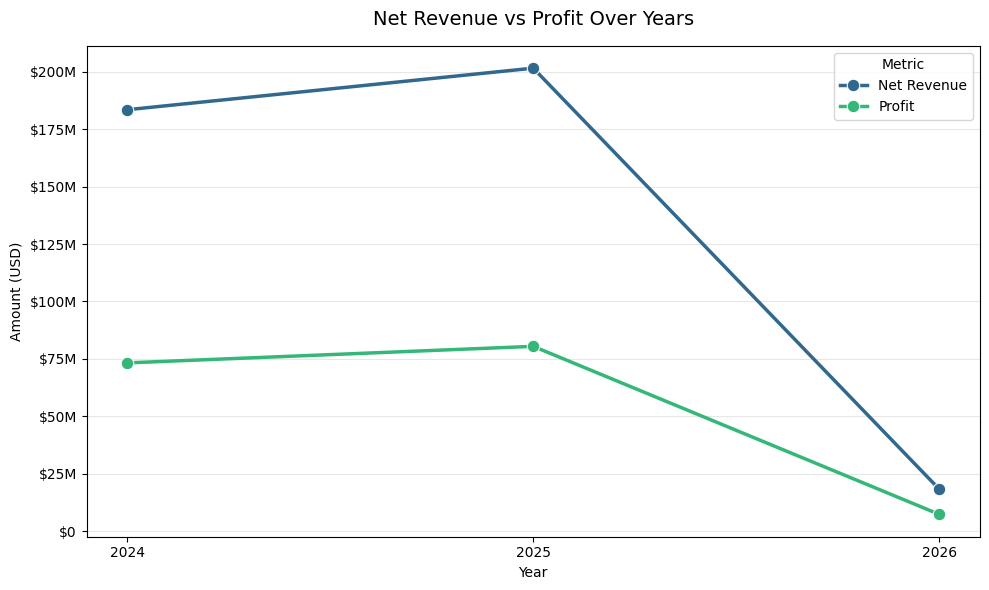

In [176]:
profit_vs_net_revenue = (
    sales_df
    .groupby('order_year')[['net_revenue_usd', 'profit_usd']]
    .sum()
    .reset_index()
)

profit_vs_net_revenue = profit_vs_net_revenue.rename(columns={
    'net_revenue_usd': 'Net Revenue',
    'profit_usd': 'Profit'
})

profit_vs_net_revenue_melted = profit_vs_net_revenue.melt(
    id_vars='order_year',
    value_vars=['Net Revenue', 'Profit'],
    var_name='metric',
    value_name='amount'
)

plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=profit_vs_net_revenue_melted,
    x='order_year',
    y='amount',
    hue='metric',
    marker='o',
    markersize=9,
    linewidth=2.5,
    palette='viridis'
)

plt.title('Net Revenue vs Profit Over Years', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Amount (USD)')
plt.xticks(profit_vs_net_revenue['order_year'])
plt.legend(title='Metric')
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Discount Analysis

### 7.1 Gross vs Net Revenue

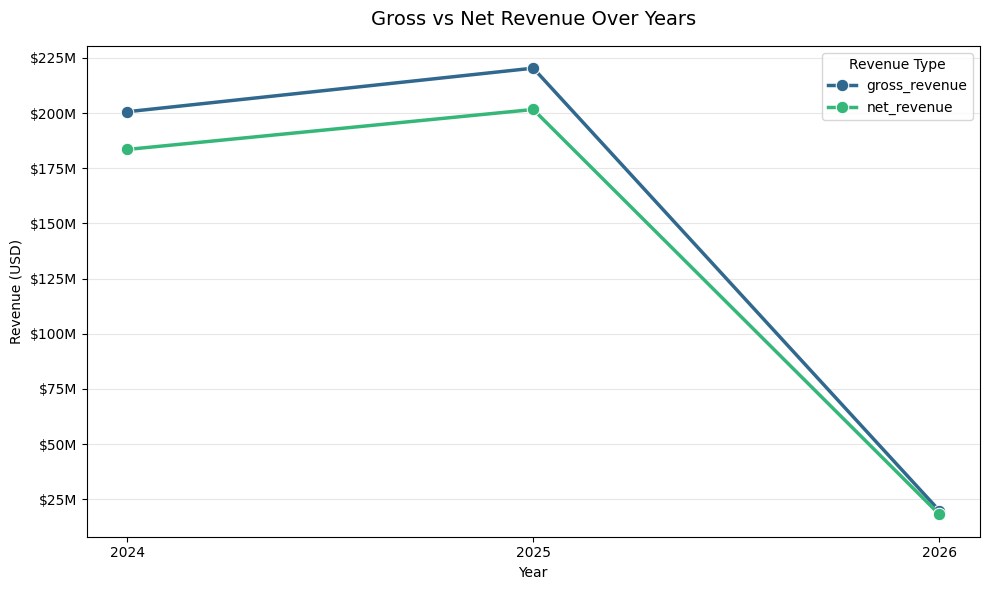

In [177]:
yearly = sales_df.groupby('order_year').agg(
    gross_revenue=('gross_revenue_usd', 'sum'),
    net_revenue=('net_revenue_usd', 'sum')
).reset_index()

# Reshape for seaborn
yearly_melted = yearly.melt(
    id_vars='order_year',
    value_vars=['gross_revenue', 'net_revenue'],
    var_name='revenue_type',
    value_name='revenue'
)

plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=yearly_melted,
    x='order_year',
    y='revenue',
    hue='revenue_type',
    marker='o',
    markersize=9,
    linewidth=2.5,
    palette='viridis'
)

plt.title('Gross vs Net Revenue Over Years', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Revenue (USD)')
plt.xticks(yearly['order_year'])
plt.legend(title='Revenue Type')
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 7.2 Discount Impact by Year

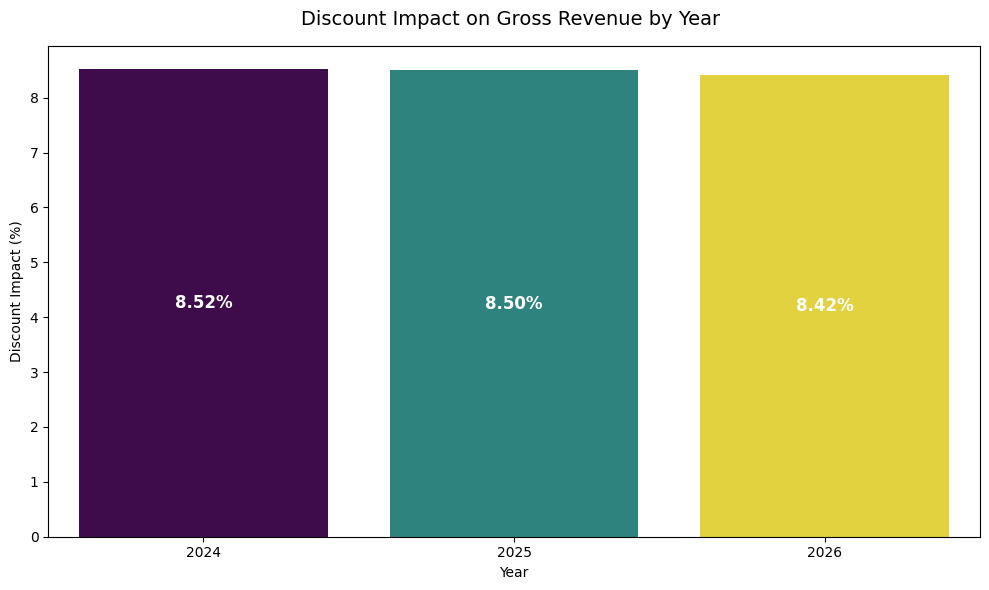

In [178]:
discount_yearly = (
    sales_df
    .groupby('order_year')
    .agg(
        gross_revenue=('gross_revenue_usd', 'sum'),
        net_revenue=('net_revenue_usd', 'sum'),
        discount_amount=('discount_amount_usd', 'sum')
    )
    .reset_index()
)

discount_yearly['discount_impact_percent'] = (
    discount_yearly['discount_amount']
    / discount_yearly['gross_revenue']
    * 100
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=discount_yearly,
    x='order_year',
    y='discount_impact_percent',
    palette='viridis',
    hue='order_year',
    legend=False
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.2f}%' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=12,
        fontweight='bold'
    )

plt.title('Discount Impact on Gross Revenue by Year ', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Discount Impact (%)')
plt.tight_layout()
plt.show()

### 7.3 Discounted vs Non-Discounted Transactions

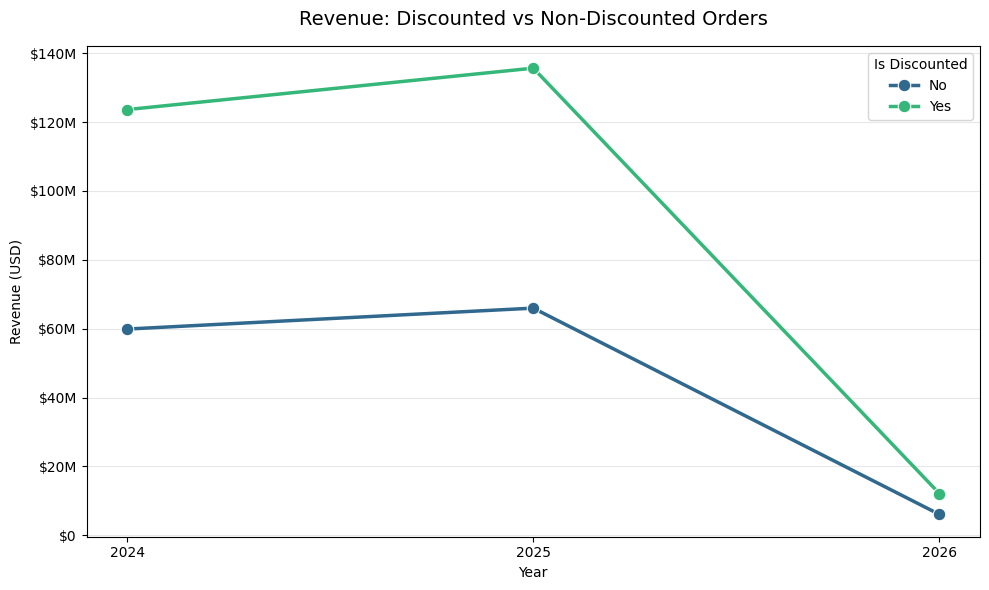

In [179]:
discount_rev = (
    sales_df.groupby(['order_year', 'is_discounted'])['net_revenue_usd']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=discount_rev,
    x='order_year',
    y='net_revenue_usd',
    hue='is_discounted',
    marker='o',
    markersize=9,
    linewidth=2.5,
    palette='viridis'
)

plt.title('Revenue: Discounted vs Non-Discounted Orders', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Revenue (USD)')
plt.xticks([2024, 2025, 2026])
plt.legend(title='Is Discounted')
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 7.4 Discounted vs Non-Discounted Profitability

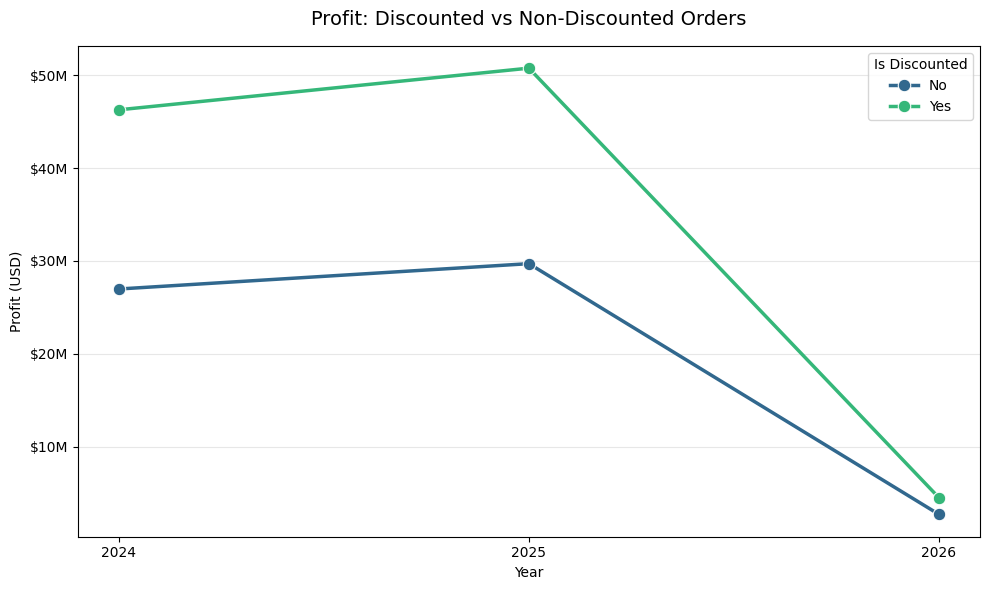

In [180]:
discount_profit = (
    sales_df.groupby(['order_year', 'is_discounted'])['profit_usd']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=discount_profit,
    x='order_year',
    y='profit_usd',
    hue='is_discounted',
    marker='o',
    markersize=9,
    linewidth=2.5,
    palette='viridis'
)

plt.title('Profit: Discounted vs Non-Discounted Orders', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Profit (USD)')
plt.xticks([2024, 2025, 2026])
plt.legend(title='Is Discounted')
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()